## **Phi_4 Model: Noise Effect**


## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

In [ ]:
# Specify the model type
MY_MODEL = 'discrete_phi_quartic' # discrete sine Gordon model 

# No seed number is used in this example.

# Generate data based on the specified model type
node_num = 30
C = 2.0 #coupling strength


#initial conditions for Simulation
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)

#x0 = np.tanh(xn/np.sqrt(1-v**2))  
num_traj = 6
v = np.linspace(0.0, 0.99, num_traj)
data_initial_conditions= []
for i in range(num_traj):
        #x0 =  np.tanh(xn/np.sqrt(1-v[i]**2))
        #d_x0 = 1/np.sqrt(1-v[i]**2) * (1 - np.tanh(xn/np.sqrt(1-v[i]**2))**2)

        x0 = np.random.normal(0, 0.1, size=xn.shape)  
        d_x0 = np.random.normal(0, 0.1, size=xn.shape)  

        new_IC = np.concatenate((x0, d_x0), axis=0) # add velocity
        data_initial_conditions.append(new_IC)

#x0 =  np.tanh(xn/np.sqrt(1-v**2))
#d_x0 = 1/np.sqrt(1-v**2) * (1 - np.tanh(xn/np.sqrt(1-v**2))**2)
#data_initial_conditions = np.concatenate((x0, d_x0), axis=0) # add velocity

data_T =  500.0       # Length of the data (T)
data_dt = 0.05     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, noise_level=0.05)

t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num)

print("Guess highest order polynomial:", guess_highest_order_polynomial)

#plot x_train and dx_train
import matplotlib.pyplot as plt
print(x_train.shape)
plt.scatter(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train


print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**

In [26]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.01

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

Used to specifly the structure of the neural network

In [ ]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial    
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[60, 60, 60]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [ ]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**


In [29]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [30]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [ ]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **Pruning Profile**

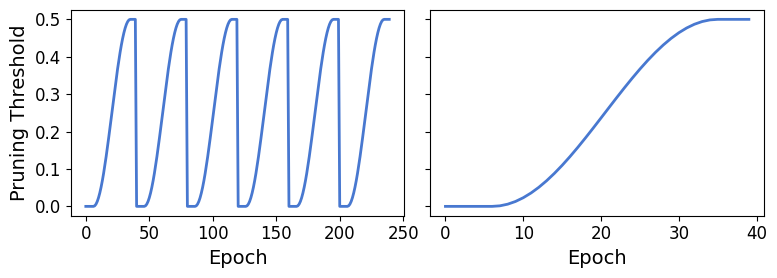

In [ ]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.5 #.3-.35 
N_PERIODS = 6
PRUNING_EPOCHS_PER_PERIOD = 40
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.15,
                    show_plot=True)


In [ ]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1.0e-2   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.3

training_histories = []
weights_list = []
loss_list = []


### **Training**

In [ ]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 60
Training dimension 1...


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Epoch   1:  Train Loss: 1.239e-01,  Validation Loss: 3.532e-01,  Epoch Time: 0.71s,  Current Pruning Threshold: 0
Epoch   2:  Train Loss: 1.454e-01,  Validation Loss: 7.387e-03,  Epoch Time: 0.38s,  Current Pruning Threshold: 0
Epoch   3:  Train Loss: 6.618e-03,  Validation Loss: 6.546e-03,  Epoch Time: 0.40s,  Current Pruning Threshold: 0
Epoch   4:  Train Loss: 6.337e-03,  Validation Loss: 6.425e-03,  Epoch Time: 0.40s,  Current Pruning Threshold: 0
Epoch   5:  Train Loss: 6.476e-03,  Validation Loss: 6.734e-03,  Epoch Time: 0.41s,  Current Pruning Threshold: 0
Epoch   6:  Train Loss: 6.841e-03,  Validation Loss: 6.814e-03,  Epoch Time: 0.39s,  Current Pruning Threshold: 0
Epoch   7:  Train Loss: 7.395e-03,  Validation Loss: 7.725e-03,  Epoch Time: 0.37s,  Current Pruning Threshold: 0
Epoch   8:  Train Loss: 8.235e-03,  Validation Loss: 8.611e-03,  Epoch Time: 0.37s,  Current Pruning Threshold: 0.0014655
Epoch   9:  Train Loss: 7.547e-03,  Validation Loss: 7.109e-03,  Epoch Time: 0.3

## **IV. Coefficient Reconstructor (SREINet)**


#### `generate_set_labels`

In [ ]:
def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [ ]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [ ]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 0.2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)'= 1.011976786*x31
(x2)'= 1.003077256*x32
(x3)'= 0.9879234181*x33
(x4)'= 1.006091644*x34
(x5)'= 0.9821706867*x35
(x6)'= 0.980525206*x36
(x7)'= 1.000088882*x37
(x8)'= 0.9933600544*x38
(x9)'= 1.007286979*x39
(x10)'= 0.9821002974*x40
(x11)'= 0.9890210106*x41
(x12)'= 1.018842799*x42
(x13)'= 1.006030913*x43
(x14)'= 0.9880309298*x44
(x15)'= 0.9928697765*x45
(x16)'= 0.9938497929*x46
(x17)'= 0.9944597206*x47
(x18)'= 0.993826833*x48
(x19)'= 0.9935824733*x49
(x20)'= 1.004266974*x50
(x21)'= 0.9902462425*x51
(x22)'= 1.011135276*x52
(x23)'= 0.9785986201*x53
(x24)'= 1.000836602*x54
(x25)'= 1.010083068*x55
(x26)'= 1.006501127*x56
(x27)'= 0.9738764605*x57
(x28)'= 1.004091791*x58
(x29)'= 1.010716853*x59
(x30)'= 1.000782029*x60
(x31)'=  - 1.960933528*x1^3 + 1.939497854*x2
(x32)'= 1.946265632*x1 - 1.962620838*x2 - 1.963431269*x2^3 + 1.952774034*x3
(x33)'= 1.926299112*x2 - 1.933122694*x3 + 1.928281008*x4 - 1.925177569*x3^3
(x34)'= 1.93629306*x3 - 1.919519566*x4 + 1.943818057*x5 - 1.941241338*x4^3
(x35